# PIF MACHINE LEARNING 

## Librerias 

In [169]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, auc
)

from imblearn.over_sampling import SMOTE

from pycaret.classification import (
    setup, compare_models, tune_model, finalize_model, predict_model, pull, get_config, models
)

RANDOM_STATE = 42

## Carga de datos 

In [156]:
ds = load_breast_cancer(as_frame=True)

X_full = ds.frame.drop(columns=["target"])
y_full = ds.frame["target"].map({0: "M", 1: "B"})

data = X_full.copy()
data["diagnosis"] = y_full

print("Dimensiones (filas, columnas):", data.shape)       
print("Nulos totales:", int(data.isnull().sum().sum()))     
print("\nDistribución de clases (B/M):")
print(data["diagnosis"].value_counts().sort_index())       

TARGET = "diagnosis"
FEATURES = X_full.columns.tolist()  

Dimensiones (filas, columnas): (569, 31)
Nulos totales: 0

Distribución de clases (B/M):
diagnosis
B    357
M    212
Name: count, dtype: int64


## Limpieza de datos y split

In [157]:
data = data.drop_duplicates().copy()
assert data.isnull().sum().sum() == 0  

X = data[FEATURES].copy()
y = data[TARGET].copy()   

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)

print("Formas -> X_train:", X_train.shape, "| X_test:", X_test.shape)

def resumen_clases(nombre, serie):
    vc = serie.value_counts().sort_index()
    b = int(vc.get('B', 0)); m = int(vc.get('M', 0))
    print(f"{nombre}: B={b} | M={m}")

resumen_clases("TRAIN (antes de SMOTE)", y_train)
resumen_clases("TEST", y_test)


Formas -> X_train: (455, 30) | X_test: (114, 30)
TRAIN (antes de SMOTE): B=285 | M=170
TEST: B=72 | M=42


## Balanceo

TRAIN antes de SMOTE: {'B': 285, 'M': 170}
TEST (sin modificar): {'B': 72, 'M': 42}
TRAIN después de SMOTE: {'B': 285, 'M': 285}


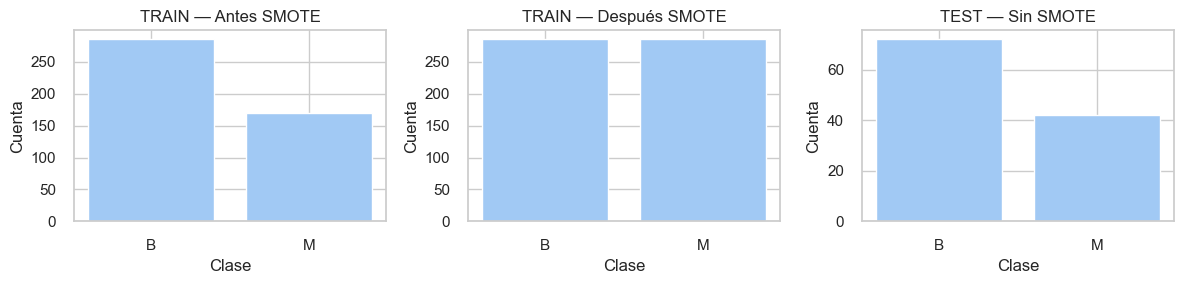

In [162]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

train_before = y_train.value_counts().sort_index()
test_dist    = y_test.value_counts().sort_index()

print("TRAIN antes de SMOTE:", dict(train_before))
print("TEST (sin modificar):", dict(test_dist))

smote = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

train_after = y_train_sm.value_counts().sort_index()
print("TRAIN después de SMOTE:", dict(train_after))

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].bar(train_before.index, train_before.values)
axes[0].set_title("TRAIN — Antes SMOTE")
axes[0].set_xlabel("Clase"); axes[0].set_ylabel("Cuenta")

axes[1].bar(train_after.index, train_after.values)
axes[1].set_title("TRAIN — Después SMOTE")
axes[1].set_xlabel("Clase"); axes[1].set_ylabel("Cuenta")

axes[2].bar(test_dist.index, test_dist.values)
axes[2].set_title("TEST — Sin SMOTE")
axes[2].set_xlabel("Clase"); axes[2].set_ylabel("Cuenta")

plt.tight_layout()
plt.show()

## Configuracion Pycaret 

In [170]:
train_df = X_train.copy(); train_df["diagnosis"] = y_train.values
test_df  = X_test.copy();  test_df["diagnosis"]  = y_test.values

# 1) Setup con tu TEST fijo y SMOTE en el pipeline de CV (no toca TEST)
exp = setup(
    data=train_df,
    test_data=test_df,
    target="diagnosis",
    session_id=RANDOM_STATE,
    fold=5,
    normalize=True,
    remove_multicollinearity=True,
    multicollinearity_threshold=0.95,
    fix_imbalance=True,
    fix_imbalance_method=SMOTE(random_state=RANDOM_STATE),
    verbose=False
)

# 2) Filtrar modelos probabilísticos realmente disponibles en este entorno
#    Candidatos con predict_proba:
prob_candidates = ['lr','lightgbm','xgboost','catboost','rf','gbc','et','lda','qda','knn','nb']
avail_tbl = models()              

cols = [c.lower() for c in avail_tbl.columns]
if 'id' in cols:
    id_col = avail_tbl.columns[cols.index('id')]
    avail_ids = set(avail_tbl[id_col].str.lower().tolist())
else:
    
    try:
        avail_ids = set(avail_tbl.index.astype(str).str.lower().tolist())
    except Exception:
        avail_ids = set()

include_list = [m for m in prob_candidates if m in avail_ids]
if not include_list:
    include_list = ['lr','rf','nb']  

print("Modelos incluidos en la comparación:", include_list)

best_model = compare_models(include=include_list, sort="AUC")
ranking_cv = pull()

tuned_model = tune_model(best_model, optimize="AUC", choose_better=True)
cv_metrics  = pull()
final_model = finalize_model(tuned_model)

print("\nMejor modelo (probabilístico):", best_model)
print("Modelo afinado:", tuned_model)
print("\nTOP por AUC (CV):")
print(ranking_cv.head(5))
print("\nMétricas CV del modelo afinado:")
print(cv_metrics)

Modelos incluidos en la comparación: ['lr', 'lightgbm', 'rf', 'gbc', 'et', 'lda', 'qda', 'knn', 'nb']


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.9670,0.9944,0.9670,0.9680,0.9670,0.9293,0.9304,0.0400
et,Extra Trees Classifier,0.9714,0.9936,0.9714,0.9719,0.9713,0.9384,0.9392,0.0640
lightgbm,Light Gradient Boosting Machine,0.9582,0.9897,0.9582,0.9588,0.9582,0.9107,0.9113,0.0940
lda,Linear Discriminant Analysis,0.9648,0.9897,0.9648,0.9660,0.9645,0.9235,0.9254,0.0240
rf,Random Forest Classifier,0.9560,0.9895,0.9560,0.9564,0.9559,0.9056,0.9062,0.0840
gbc,Gradient Boosting Classifier,0.9363,0.9888,0.9363,0.9393,0.9364,0.8654,0.8679,0.1380
qda,Quadratic Discriminant Analysis,0.9516,0.9877,0.9516,0.9526,0.9518,0.8974,0.8980,0.0240
knn,K Neighbors Classifier,0.9516,0.9827,0.9516,0.9519,0.9516,0.8964,0.8968,0.0280
nb,Naive Bayes,0.9341,0.9753,0.9341,0.9341,0.9339,0.8585,0.8588,0.0340


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9780,0.9985,0.9780,0.9788,0.9779,0.9525,0.9536
1,0.9890,1.0000,0.9890,0.9893,0.9890,0.9767,0.9769
2,0.9560,0.9871,0.9560,0.9589,0.9554,0.9038,0.9080
3,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
4,0.9121,0.9923,0.9121,0.9139,0.9126,0.8144,0.8153
Mean,0.9670,0.9956,0.9670,0.9682,0.9670,0.9295,0.9308
Std,0.0311,0.0051,0.0311,0.0303,0.0310,0.0658,0.0653


Fitting 5 folds for each of 10 candidates, totalling 50 fits

Mejor modelo (probabilístico): LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)
Modelo afinado: LogisticRegression(C=8.426, class_weight='balanced', dual=False,
                   fit_intercept=True, intercept_scaling=1, l1_ratio=None,
                   max_iter=1000, multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

TOP por AUC (CV):
                                    Model  Accuracy     AUC  Recall   Prec.  \
lr                    Logistic Regression    0.9670  0.9944  0.9670  0.9680   
et                 Extra Trees Classifier    0.9714  0.9

## Metricas de rendimiento 

In [182]:
def _label_col(df):
    for c in ("prediction_label", "Label"):
        if c in df.columns:
            return c
    return None

def _score_col(df):
    for c in ("prediction_score", "Score"):
        if c in df.columns:
            return c
    return None

def _prob_M_from_scores(df):
    """
    Intenta extraer probabilidad de la clase 'M' de varias formas:
    1) Columnas 'Score_*' (v2): usa 'Score_M' o 1 - 'Score_B'.
    2) Columnas 'prediction_score'/'Score' + label: si la etiqueta predicha es M, pM=score; si es B, pM=1-score.
    """

    score_cols = [c for c in df.columns if c.startswith("Score_")]
    if score_cols:
        if "Score_M" in score_cols:
            return df["Score_M"].astype(float).values
        if "Score_B" in score_cols:
            return 1.0 - df["Score_B"].astype(float).values
        if len(score_cols) == 2:
            other = [c for c in score_cols if not c.endswith("_B")][0]
            return df[other].astype(float).values

    labc = _label_col(df)
    sc   = _score_col(df)
    if labc is not None and sc is not None:
        lbl = df[labc].map({0:"B", 1:"M", "B":"B", "M":"M", "benign":"B", "malignant":"M"})
        s   = df[sc].astype(float).values
        return np.where(lbl.values == "M", s, 1.0 - s)

    if labc is not None:
        lbl = df[labc].map({0:"B", 1:"M", "B":"B", "M":"M", "benign":"B", "malignant":"M"})
        return (lbl == "M").astype(int).values.astype(float)

    raise KeyError("No fue posible inferir prob(M) de las columnas devueltas por predict_model().")

def _compute_metrics(df_pred):
   
    y_true = df_pred["diagnosis"].map({0:"B", 1:"M", "B":"B", "M":"M", "benign":"B", "malignant":"M"})
    
    labc = _label_col(df_pred)
    if labc is None:
        raise KeyError("No se encontró la columna de etiqueta predicha (prediction_label/Label).")
    y_pred = df_pred[labc].map({0:"B", 1:"M", "B":"B", "M":"M", "benign":"B", "malignant":"M"})

    pM = _prob_M_from_scores(df_pred)

    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, pos_label="M"),
        "Recall":    recall_score(y_true, y_pred, pos_label="M"),
        "F1":        f1_score(y_true, y_pred, pos_label="M"),
        "AUC-ROC":   roc_auc_score((y_true=="M").astype(int), pM),
    }

sm = SMOTE(random_state=RANDOM_STATE, k_neighbors=5)
X_train_sm, y_train_sm = sm.fit_resample(X_train[FEATURES], y_train)

train_bal_df = pd.DataFrame(X_train_sm, columns=FEATURES)
train_bal_df["diagnosis"] = y_train_sm

pred_train_bal = predict_model(tuned_model, data=train_bal_df, raw_score=True)
pred_test      = predict_model(tuned_model, data=test_df,      raw_score=True)

m_train = _compute_metrics(pred_train_bal)
m_test  = _compute_metrics(pred_test)

metrics_df = pd.DataFrame([m_train, m_test], index=["Train (SMOTE)", "Test"]).round(4)
print("Métricas — Train balanceado (SMOTE) vs Test ")
print(metrics_df)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9895,0.9996,0.9895,0.9896,0.9895,0.9789,0.9790


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9737,0.9861,0.9737,0.9737,0.9736,0.9432,0.9433


Métricas — Train balanceado (SMOTE) vs Test 
               Accuracy  Precision  Recall      F1  AUC-ROC
Train (SMOTE)    0.9895     0.9964  0.9825  0.9894   0.9895
Test             0.9737     0.9756  0.9524  0.9639   0.9692


## Matrices de confusión

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9895,0.9996,0.9895,0.9896,0.9895,0.9789,0.9790


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9737,0.9861,0.9737,0.9737,0.9736,0.9432,0.9433


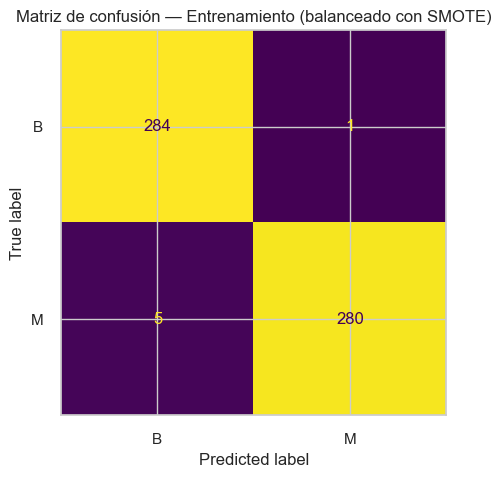

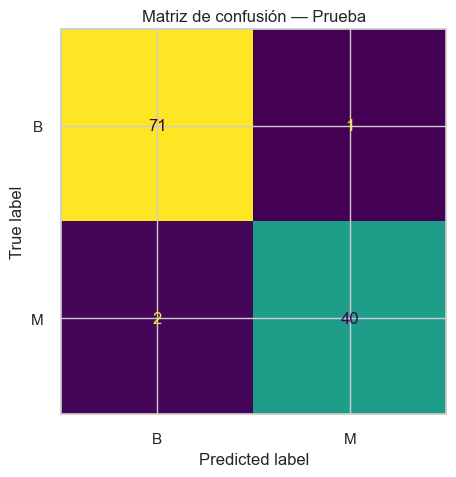

In [184]:
pred_train_bal = predict_model(tuned_model, data=train_bal_df)  
pred_test      = predict_model(tuned_model, data=test_df)       

def _label_col(df):
    for c in ("prediction_label", "Label"):
        if c in df.columns:
            return c
    raise KeyError("No se encontró la columna de etiqueta predicha (prediction_label/Label).")

def _to_BM(s):
    return s.map({0:"B",1:"M","B":"B","M":"M","benign":"B","malignant":"M"})

y_tr_true = _to_BM(pred_train_bal["diagnosis"])
y_tr_pred = _to_BM(pred_train_bal[_label_col(pred_train_bal)])

cm_tr = confusion_matrix(y_tr_true, y_tr_pred, labels=["B","M"])
ConfusionMatrixDisplay(cm_tr, display_labels=["B","M"]).plot(values_format="d", colorbar=False)
plt.title("Matriz de confusión — Entrenamiento (balanceado con SMOTE)")
plt.show()

y_te_true = _to_BM(pred_test["diagnosis"])
y_te_pred = _to_BM(pred_test[_label_col(pred_test)])

cm_te = confusion_matrix(y_te_true, y_te_pred, labels=["B","M"])
ConfusionMatrixDisplay(cm_te, display_labels=["B","M"]).plot(values_format="d", colorbar=False)
plt.title("Matriz de confusión — Prueba")
plt.show()

## Curvas AUC-ROC

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9895,0.9996,0.9895,0.9896,0.9895,0.9789,0.9790


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.9737,0.9861,0.9737,0.9737,0.9736,0.9432,0.9433


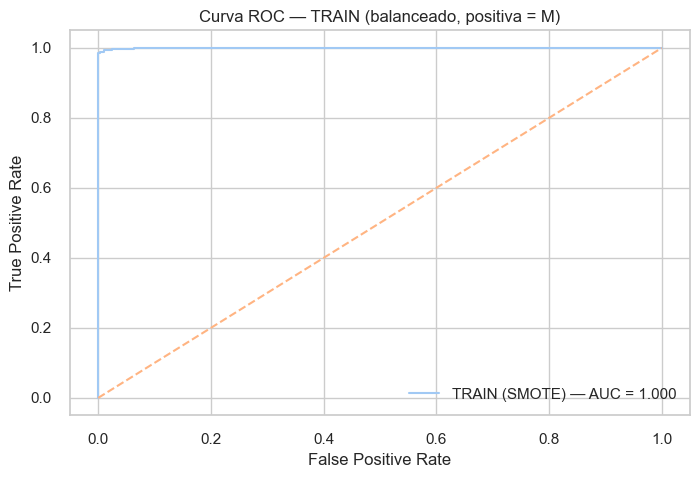

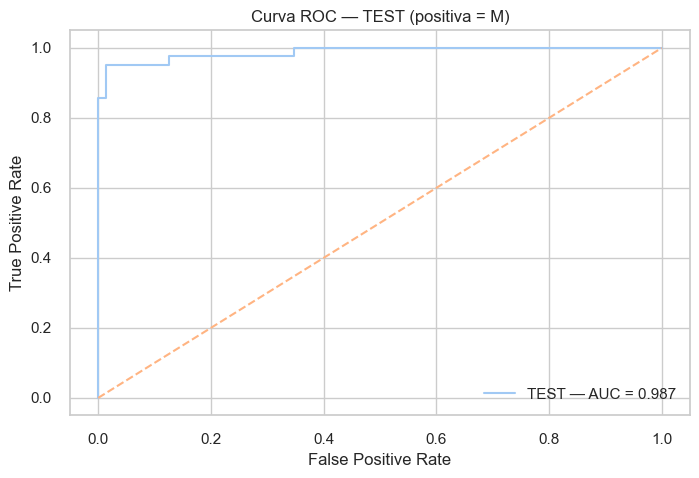

In [177]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from pycaret.classification import predict_model

# --------- helpers ---------
def prob_M_from_predict_model(df):
    # 1) Score_* (PyCaret v2)
    if 'Score_M' in df.columns:
        return df['Score_M'].astype(float).values
    if 'Score_B' in df.columns:
        return 1.0 - df['Score_B'].astype(float).values
    scols = [c for c in df.columns if c.startswith('Score_')]
    if len(scols) == 2:
        # tomar la que no sea B; se asume que corresponde a M
        other = [c for c in scols if not c.endswith('_B')][0]
        return df[other].astype(float).values

    # 2) label + prediction_score / Score (v3/v2)
    lab_col = 'prediction_label' if 'prediction_label' in df.columns else ('Label' if 'Label' in df.columns else None)
    scr_col = 'prediction_score' if 'prediction_score' in df.columns else ('Score' if 'Score' in df.columns else None)
    if lab_col and scr_col:
        lab = df[lab_col].map({0:'B',1:'M','B':'B','M':'M','benign':'B','malignant':'M'})
        scr = df[scr_col].astype(float).values
        return np.where(lab.values == 'M', scr, 1.0 - scr)

    raise KeyError("No hay columnas de probabilidad accesibles en predict_model().")

def make_scores_robust(train_bal_df, test_df):
    """
    Fallback: clona tuned_model y arma un pipeline scikit (scaler + modelo) para obtener_probabilidades.
    """
    est = clone(tuned_model)
    pipe = make_pipeline(StandardScaler(), est)

    X_trb = train_bal_df.drop(columns=['diagnosis'])
    y_trb = train_bal_df['diagnosis']
    X_te  = test_df.drop(columns=['diagnosis'])
    y_te  = test_df['diagnosis']

    pipe.fit(X_trb, y_trb)  # ajustamos en el TRAIN balanceado (coincide con tus matrices de chunk 7)
    classes = list(pipe.steps[-1][1].classes_)
    pos_idx = classes.index('M') if 'M' in classes else 1

    p_tr = pipe.predict_proba(X_trb)[:, pos_idx]
    p_te = pipe.predict_proba(X_te)[:, pos_idx]
    return (y_trb, p_tr), (y_te, p_te)

def binarize_M(y):
    return (np.array(y) == 'M').astype(int)

# --------- intento 1: usar predict_model ---------
try:
    # Reutilizamos los mismos dataframes de los chunks 6–7
    pred_train_bal = predict_model(tuned_model, data=train_bal_df, raw_score=True)
    pred_test      = predict_model(tuned_model, data=test_df,      raw_score=True)

    y_tr = pred_train_bal['diagnosis'].map({0:'B',1:'M','B':'B','M':'M','benign':'B','malignant':'M'})
    y_te = pred_test['diagnosis'].map({0:'B',1:'M','B':'B','M':'M','benign':'B','malignant':'M'})
    p_tr = prob_M_from_predict_model(pred_train_bal)
    p_te = prob_M_from_predict_model(pred_test)

except Exception:
    # --------- intento 2 (fallback): pipeline scikit con tuned_model clonado ---------
    (y_tr, p_tr), (y_te, p_te) = make_scores_robust(train_bal_df, test_df)

# --------- curvas ROC ---------
from sklearn.metrics import RocCurveDisplay

y_tr_bin = binarize_M(y_tr)
y_te_bin = binarize_M(y_te)

fpr_tr, tpr_tr, _ = roc_curve(y_tr_bin, p_tr); auc_tr = auc(fpr_tr, tpr_tr)
fpr_te, tpr_te, _ = roc_curve(y_te_bin, p_te); auc_te = auc(fpr_te, tpr_te)

plt.figure()
plt.plot(fpr_tr, tpr_tr, label=f"TRAIN (SMOTE) — AUC = {auc_tr:.3f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Curva ROC — TRAIN (balanceado, positiva = M)")
plt.legend(loc="lower right"); plt.show()

plt.figure()
plt.plot(fpr_te, tpr_te, label=f"TEST — AUC = {auc_te:.3f}")
plt.plot([0,1], [0,1], '--')
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Curva ROC — TEST (positiva = M)")
plt.legend(loc="lower right"); plt.show()

## SHAP

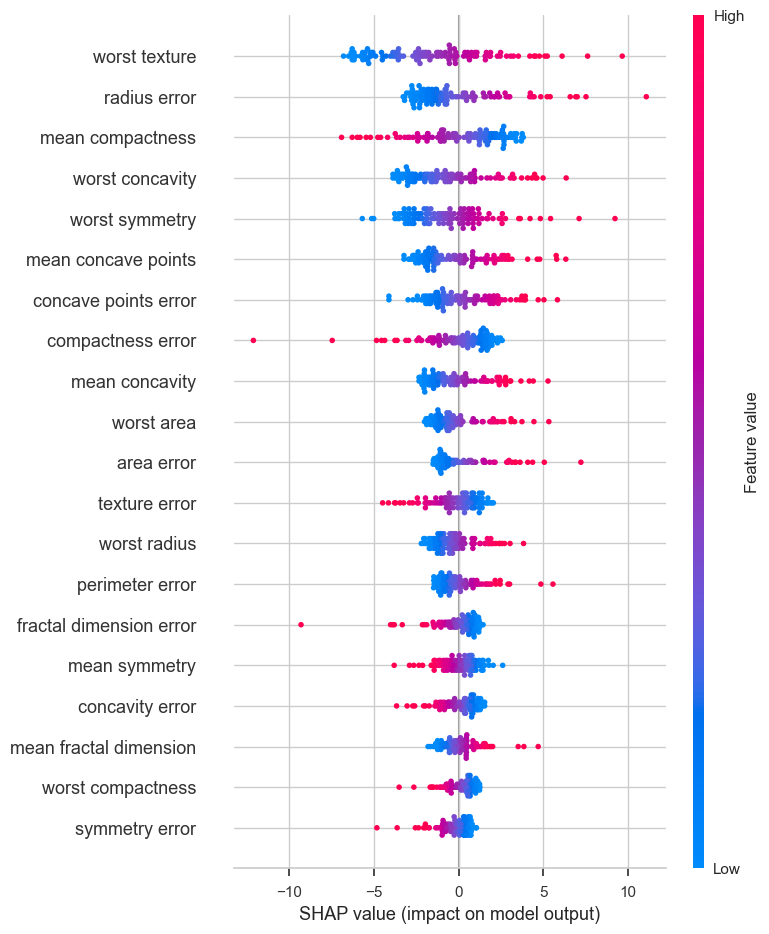

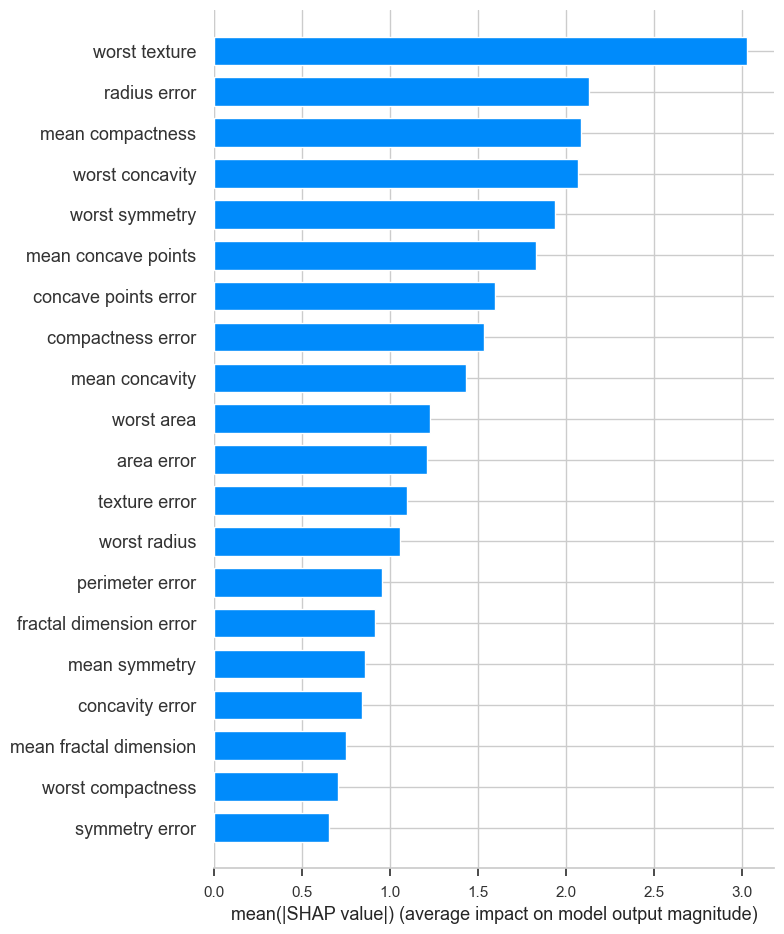

In [178]:
# === CHUNK 9: SHAP (impacto e importancia media) ===
import shap
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

# 1) Reconstruimos un pipeline simple y estable (scaler + mejor modelo de PyCaret)
est = clone(tuned_model)  # mismos hiperparámetros que el modelo afinado
pipe = make_pipeline(StandardScaler(), est)

# 2) Reentrenamos el pipeline sobre el TRAIN balanceado (coincide con las métricas/curvas previas)
X_trb = train_bal_df.drop(columns=['diagnosis']).values
y_trb = train_bal_df['diagnosis'].values
pipe.fit(X_trb, y_trb)

# 3) Preparamos datos para explicación (usamos TEST para explicar generalización)
X_te_mat = test_df.drop(columns=['diagnosis']).values
feature_names = FEATURES

# Obtenemos el modelo y el scaler ya ajustados
scaler = pipe.named_steps['standardscaler']
model  = pipe.steps[-1][1]

X_bg   = scaler.transform(X_trb)   # background (train balanceado, escalado)
X_te_s = scaler.transform(X_te_mat)

# 4) Explainer adecuado (lineal si es LR; si cambiaste a un árbol, shap.Explainer elegirá TreeExplainer)
try:
    explainer = shap.LinearExplainer(model, X_bg)
    sv = explainer.shap_values(X_te_s)
except Exception:
    explainer = shap.Explainer(model, X_bg)  # fallback general
    sv = explainer(X_te_s).values if hasattr(explainer(X_te_s), "values") else explainer(X_te_s)

# 5) Gráficas SHAP
# a) Impacto por observación (beeswarm)
shap.summary_plot(sv, X_te_s, feature_names=feature_names, show=True, plot_type='dot')

# b) Importancia media (|SHAP|) por variable (bar)
shap.summary_plot(sv, X_te_s, feature_names=feature_names, show=True, plot_type='bar')


=== Métricas en TEST por umbral seleccionado ===
               threshold  Accuracy  Precision  Recall      F1  Specificity  \
Base (0.50)        0.500    0.9737     0.9756  0.9524  0.9639       0.9861   
Youden J           0.293    0.9737     0.9756  0.9524  0.9639       0.9861   
Recall ≥ 0.98      0.000    0.3684     0.3684  1.0000  0.5385       0.0000   
Max F2             0.293    0.9737     0.9756  0.9524  0.9639       0.9861   

                   F2    TN    FP   FN    TP  
Base (0.50)    0.9569  71.0   1.0  2.0  40.0  
Youden J       0.9569  71.0   1.0  2.0  40.0  
Recall ≥ 0.98  0.7447   0.0  72.0  0.0  42.0  
Max F2         0.9569  71.0   1.0  2.0  40.0  


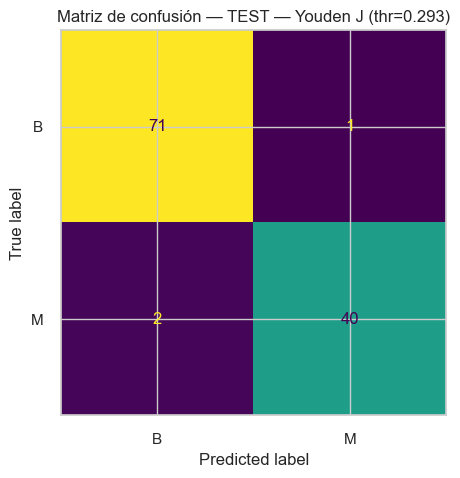

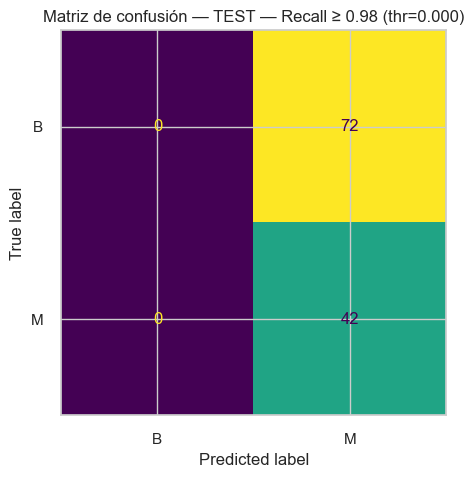

In [179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score
)
from pycaret.classification import get_config

# 1) Probabilidades de la clase positiva (M) en TEST, usando el modelo afinado y features transformados por PyCaret
Xte_t = get_config('X_test_transformed')
y_te  = get_config('y_test')                      # etiquetas 'B'/'M'
classes = list(getattr(tuned_model, "classes_", []))
pos_idx = classes.index('M') if 'M' in classes else 1
p_te = tuned_model.predict_proba(Xte_t)[:, pos_idx]
y_bin = (np.array(y_te) == 'M').astype(int)

# 2) Barrido de umbrales y métricas
thr_grid = np.linspace(0, 1, 1001)

def metrics_at_threshold(y_true_bin, probs, thr):
    y_pred_bin = (probs >= thr).astype(int)
    acc = accuracy_score(y_true_bin, y_pred_bin)
    rec = recall_score(y_true_bin, y_pred_bin, zero_division=0)         # Sensibilidad
    pre = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    f1  = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0                     # Especificidad
    # F2 (recall pondera el doble que precision)
    beta = 2
    f2 = (1+beta**2) * (pre*rec) / (beta**2*pre + rec) if (pre+rec) > 0 else 0.0
    return acc, pre, rec, f1, spec, f2, (tn, fp, fn, tp)

rows = []
for t in thr_grid:
    acc, pre, rec, f1, spec, f2, cm = metrics_at_threshold(y_bin, p_te, t)
    rows.append((t, acc, pre, rec, f1, spec, f2, cm))

res = pd.DataFrame(rows, columns=["threshold","accuracy","precision","recall","f1","specificity","f2","cm"])

# 3) Selección de umbrales
# 3.1 Youden J = sensibilidad + especificidad - 1
res["youdenJ"] = res["recall"] + res["specificity"] - 1
t_youden = res.loc[res["youdenJ"].idxmax(), "threshold"]

# 3.2 Primer umbral con Recall >= 0.98 (prioriza sensibilidad)
candid = res[res["recall"] >= 0.98]
t_recall98 = candid.iloc[0]["threshold"] if not candid.empty else 0.5   # fallback

# 3.3 Umbral que maximiza F2 (recall pesa más que precision)
t_f2 = res.loc[res["f2"].idxmax(), "threshold"]

# 3.4 Punto base 0.50
t_base = 0.50

selected = {
    "Base (0.50)": t_base,
    "Youden J": t_youden,
    "Recall ≥ 0.98": t_recall98,
    "Max F2": t_f2
}

# 4) Tabla comparativa de métricas en cada umbral seleccionado
def summarize(thr):
    acc, pre, rec, f1, spec, f2, cm = metrics_at_threshold(y_bin, p_te, thr)
    tn, fp, fn, tp = cm
    return {
        "threshold": round(thr, 3),
        "Accuracy": round(acc, 4),
        "Precision": round(pre, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
        "Specificity": round(spec, 4),
        "F2": round(f2, 4),
        "TN": tn, "FP": fp, "FN": fn, "TP": tp
    }

summary_df = pd.DataFrame({name: summarize(t) for name, t in selected.items()}).T
print("=== Métricas en TEST por umbral seleccionado ===")
print(summary_df)

# 5) Matrices de confusión para Youden J y Recall≥0.98
for label, thr in [("Youden J", t_youden), ("Recall ≥ 0.98", t_recall98)]:
    y_pred = (p_te >= thr).astype(int)
    cm = confusion_matrix(y_bin, y_pred, labels=[0,1])
    fig, ax = plt.subplots()
    ConfusionMatrixDisplay(cm, display_labels=["B","M"]).plot(values_format='d', colorbar=False, ax=ax)
    ax.set_title(f"Matriz de confusión — TEST — {label} (thr={thr:.3f})")
    plt.show()